In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [2]:
# set random seed for reproducibility
np.random.seed(42)

In [3]:
# load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [4]:
X_class

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [5]:
y_class

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [6]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [7]:
X_reg

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [8]:
y_reg

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [9]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [10]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [11]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [12]:
param_grid = {
    'C' : [0.1, 1, 10, 100],
    'gamma' : [0.001, 0.01, 0.1, 1],
    'kernel' : ['rbf', 'poly']
}

In [13]:
# Create SVC classifier
svm = SVC(random_state=42)

In [14]:
# Create a GridSearchCV Object :
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [15]:
# Start timing
start_time = time.time()

In [16]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [17]:
# End timing
grid_time = time.time() - start_time

In [18]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 4.94 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [19]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [20]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

In [21]:
grid_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.016440,0.005172,0.007887,0.002199,0.1,0.001,rbf,"{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}",0.747253,0.703297,...,0.712088,0.022413,23,0.708791,0.719780,0.695055,0.725275,0.708791,0.711538,0.010425
1,0.008463,0.001694,0.003654,0.002186,0.1,0.001,poly,"{'C': 0.1, 'gamma': 0.001, 'kernel': 'poly'}",0.637363,0.626374,...,0.628571,0.004396,29,0.626374,0.629121,0.629121,0.629121,0.629121,0.628571,0.001099
2,0.012753,0.002986,0.004765,0.001519,0.1,0.010,rbf,"{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}",0.934066,0.934066,...,0.940659,0.008791,17,0.945055,0.945055,0.934066,0.947802,0.947802,0.943956,0.005095
3,0.019153,0.002308,0.006478,0.000807,0.1,0.010,poly,"{'C': 0.1, 'gamma': 0.01, 'kernel': 'poly'}",0.681319,0.648352,...,0.661538,0.021308,24,0.664835,0.667582,0.659341,0.675824,0.662088,0.665934,0.005657
4,0.020057,0.001820,0.007422,0.000745,0.1,0.100,rbf,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}",0.912088,0.934066,...,0.936264,0.014579,18,0.969780,0.969780,0.969780,0.975275,0.975275,0.971978,0.002692


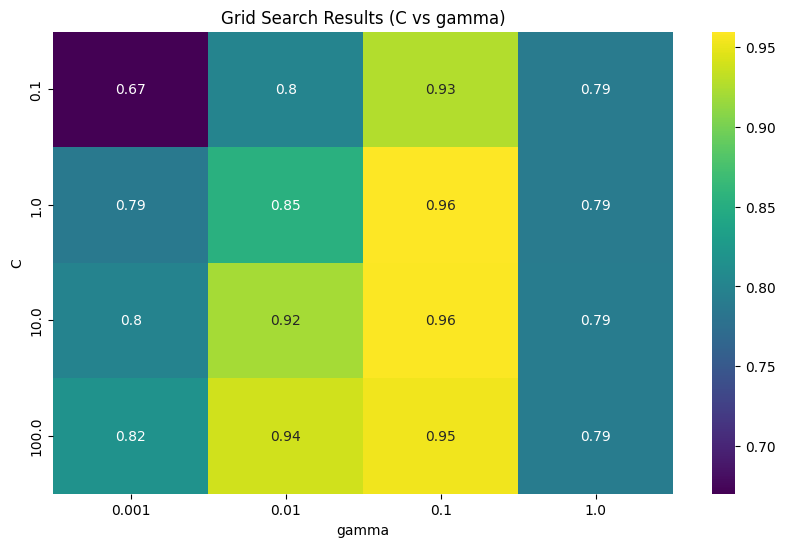

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()

# Part 2: Random Search for SVM Classifier

In [23]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}

In [24]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [25]:
# Start timing
start_time = time.time()
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)
# End timing
random_time = time.time() - start_time

In [26]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 1.01 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [27]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [28]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456            4.944994
1  Random Search       0.971429       0.964912            1.005246


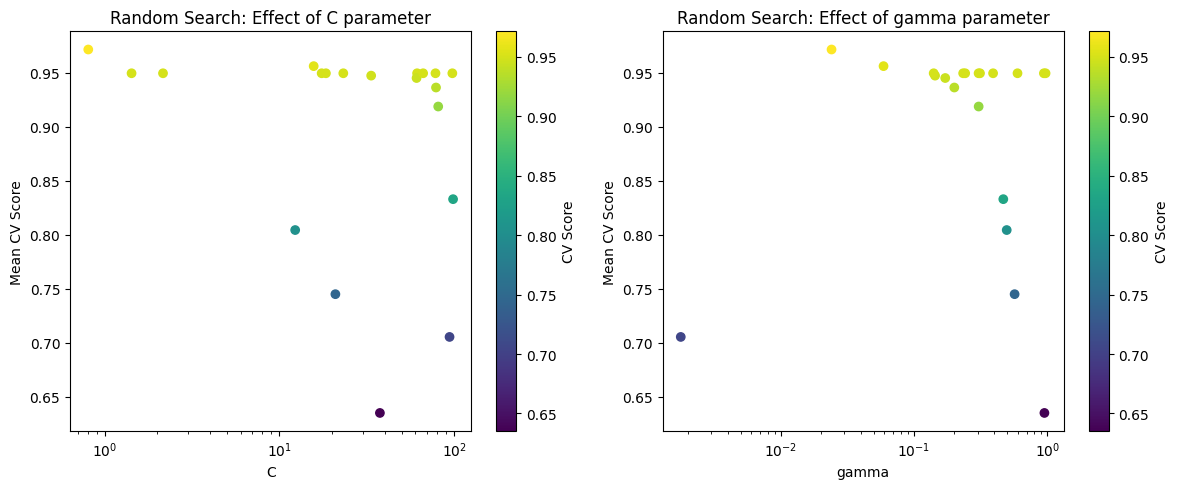

In [29]:
# visualize random search results - plot parameter samples and their scores

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(random_search.cv_results_['param_C'],
           random_search.cv_results_['mean_test_score'],
           c=random_search.cv_results_['mean_test_score'],
           cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [30]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.0 MB/s eta 0:00:00


In [31]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [32]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [33]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [34]:
# Start timing
start_time = time.time()
# fitting the BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)
# End timing
bayes_time = time.time() - start_time

In [35]:
print(f'Bayes Optiminzation completed in : {bayes_time:.2f}')
print(f"Best parameters : {bayes_search.best_params_}")
print(f'Best cross-validation score : {bayes_search.best_score_:.2f}')

Bayes Optiminzation completed in : 31.64
Best parameters : OrderedDict({'C': 47.479208101330435, 'gamma': 0.01504196942704713, 'kernel': 'rbf'})
Best cross-validation score : 0.96


In [36]:
# Evaluate on test data :
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [37]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            4.944994
1          Random Search       0.971429       0.964912            1.005246
2  Bayesian Optimization       0.962637       0.956140           31.636056


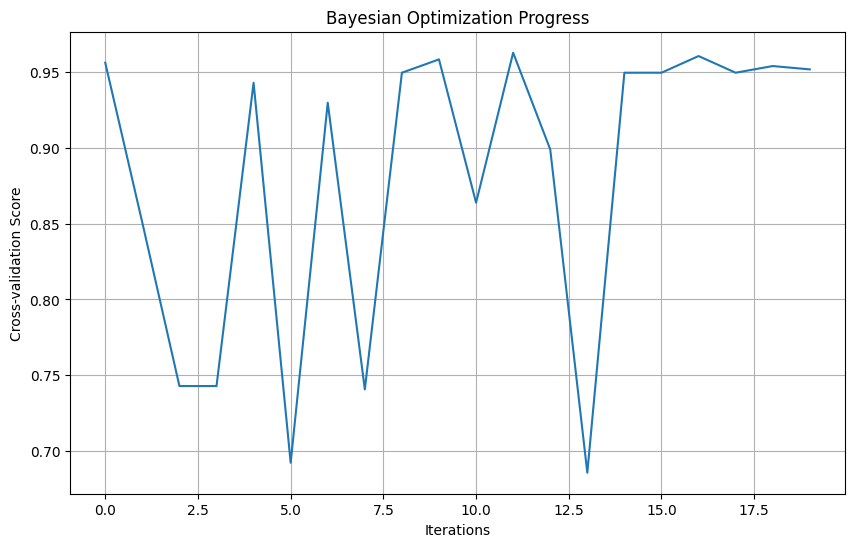

In [38]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [39]:
# Create a pipeline for regression :
rf_pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [40]:
# Defining parameter distribution for random search
rf_param_dist = {
    'regressor__n_estimators' : randint(10,200),
    'regressor__max_depth' : randint(3,20),
    'regressor__min_samples_split' : randint(2,20),
    'regressor__min_samples_leaf' : randint(1,10),
    'regressor__max_features' : ['auto', 'sqrt', 'log2', None]
}

In [41]:
# Create RandomizedSearchCV for regression :
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score = True
)

In [42]:
# Start time :
start_time = time.time()
# Fit RandomizedSearchCV :
rf_random_search.fit(X_reg_train, y_reg_train)
# End Time
rf_random_time = time.time() - start_time

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

In [43]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 25.92 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [44]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [45]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

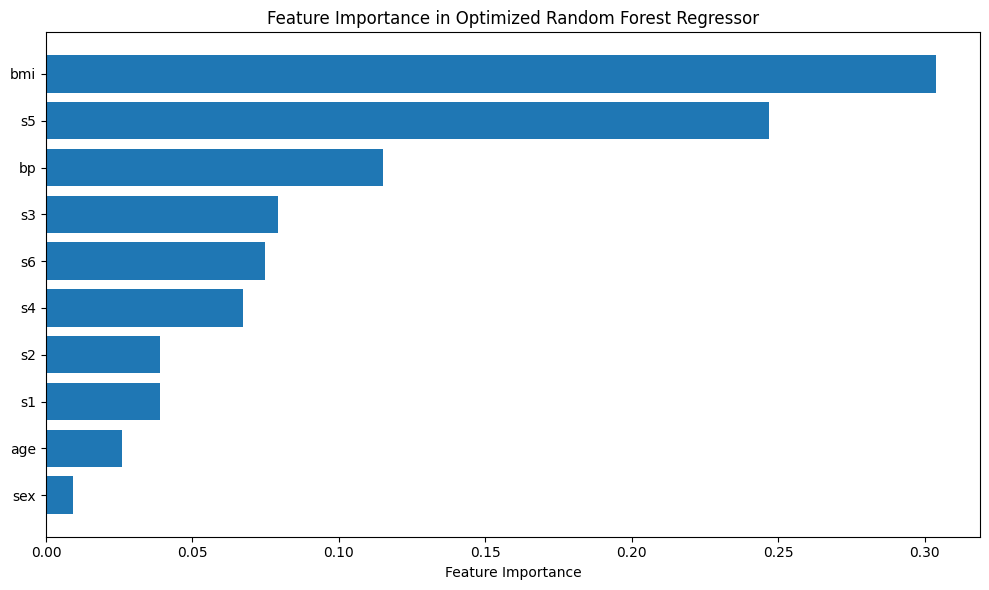

In [46]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [47]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [48]:
from sklearn.model_selection import learning_curve

In [49]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

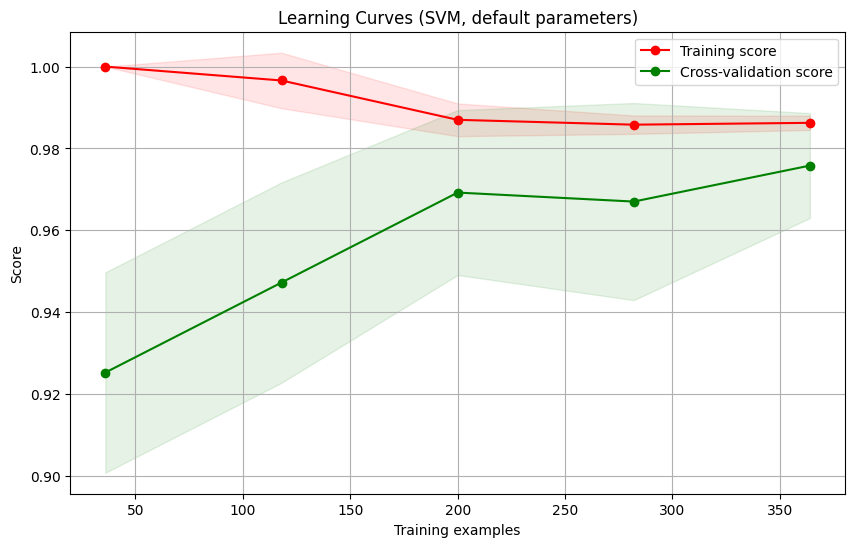

In [50]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

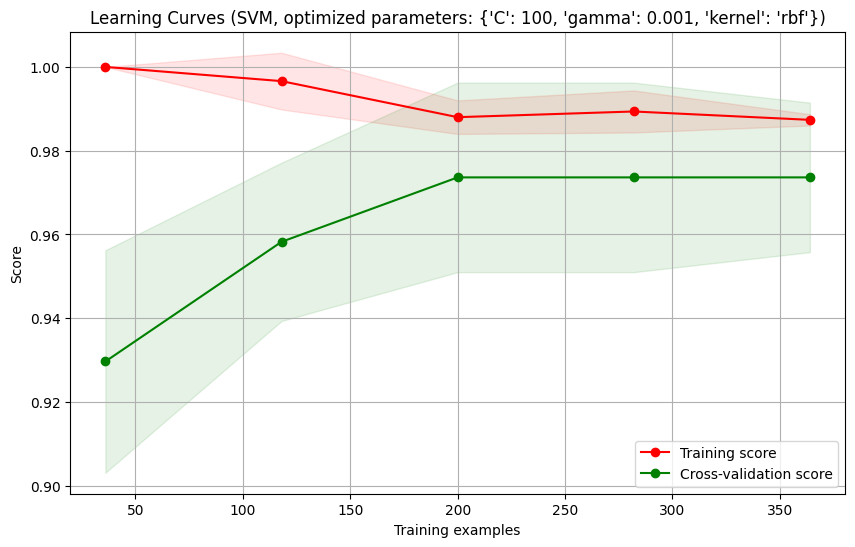

In [51]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [52]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

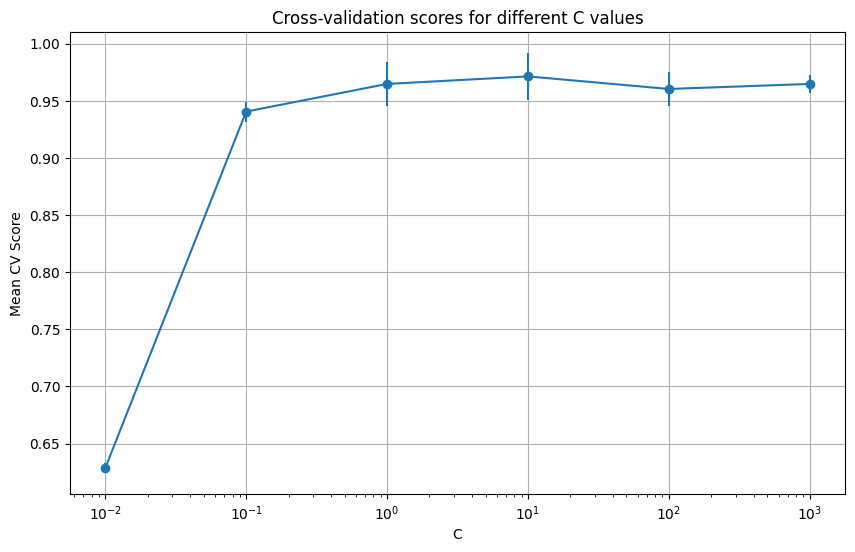

In [53]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

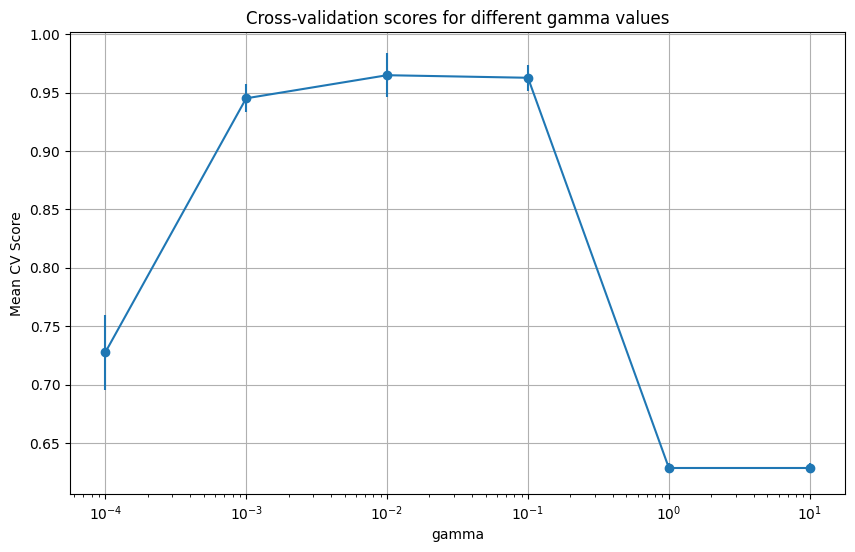

In [54]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [55]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [56]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [57]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")

Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [58]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [59]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [60]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ccd1055d1f0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ccd096c5820>,
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy')

In [61]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [62]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [63]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)

In [64]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [65]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            4.944994
1          Random Search       0.971429       0.964912            1.005246
2  Bayesian Optimization       0.962637       0.956140           31.636056
3      Combined Approach       0.978022       0.982456                 NaN


/tmp/ipykernel_542/3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [67]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

SVC(C=47.479208101330435, gamma=0.01504196942704713, probability=True,
    random_state=42)

In [68]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [69]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

RandomForestRegressor(random_state=42)

In [70]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

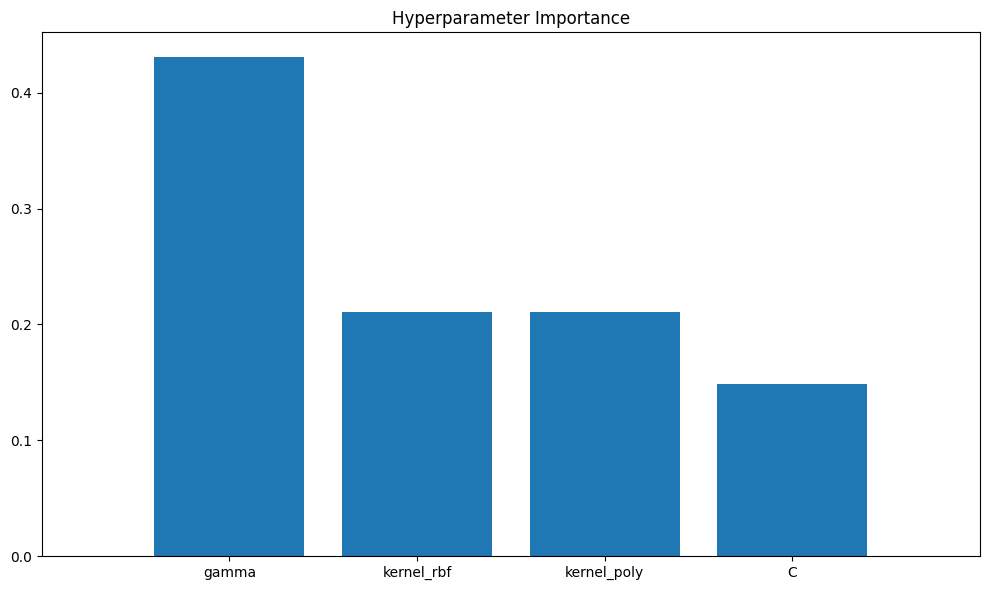

In [71]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [72]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

/tmp/ipykernel_542/149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


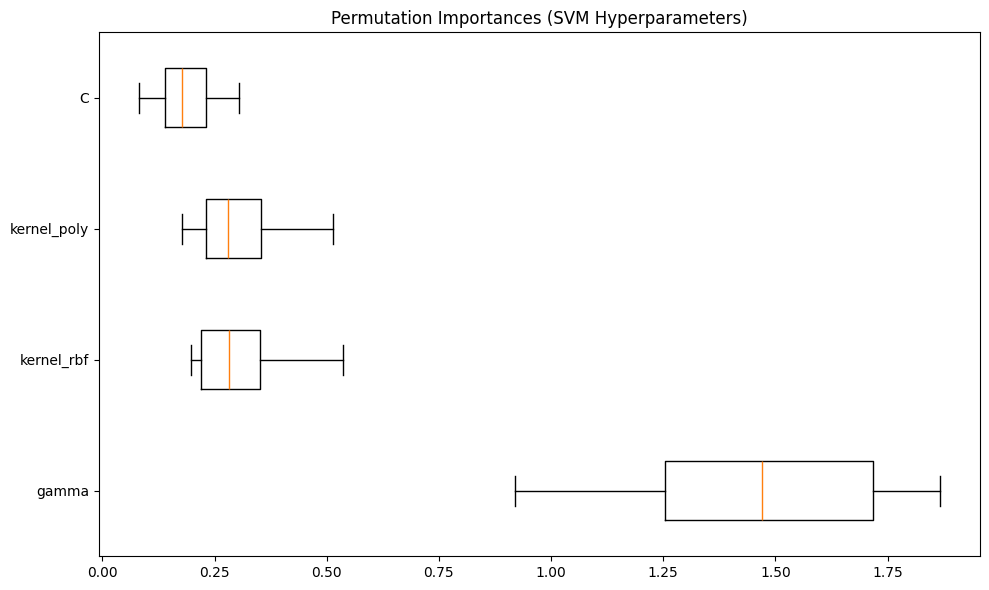

In [73]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

## Exercise

## Part 1 : Setup and Data Preparation

In [74]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Part 2: Baseline Models

In [79]:
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

# TODO: Create a dictionary of baseline models with default parameters
models = {
    'Ridge': Ridge(random_state=42),
    'SVR': SVR(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

In [83]:
# TODO: Evaluate baseline models using 5-fold cross-validation
baseline_results = {}
for name, model in models.items():
    start = time.time()
    r2_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    rmse_scores = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
    elapsed = time.time() - start
    baseline_results[name] = {
        'RMSE_mean': rmse_scores.mean(), 'RMSE_std': rmse_scores.std(),
        'R2_mean': r2_scores.mean(), 'R2_std': r2_scores.std(), 'time': elapsed
    }
    print(f"{name}: RMSE = {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}, "
          f"R² = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

baseline_df = pd.DataFrame(baseline_results).T
print(baseline_df)

Ridge: RMSE = 0.7205 ± 0.0103, R² = 0.6115 ± 0.0065
SVR: RMSE = 0.5931 ± 0.0106, R² = 0.7368 ± 0.0048
Random Forest: RMSE = 0.5115 ± 0.0044, R² = 0.8042 ± 0.0053
Gradient Boosting: RMSE = 0.5340 ± 0.0071, R² = 0.7866 ± 0.0032
                   RMSE_mean  RMSE_std   R2_mean    R2_std        time
Ridge               0.720527  0.010280  0.611484  0.006460    0.059322
SVR                 0.593056  0.010570  0.736814  0.004814   85.512848
Random Forest       0.511458  0.004399  0.804169  0.005324  145.157995
Gradient Boosting   0.534012  0.007127  0.786592  0.003211   40.131955


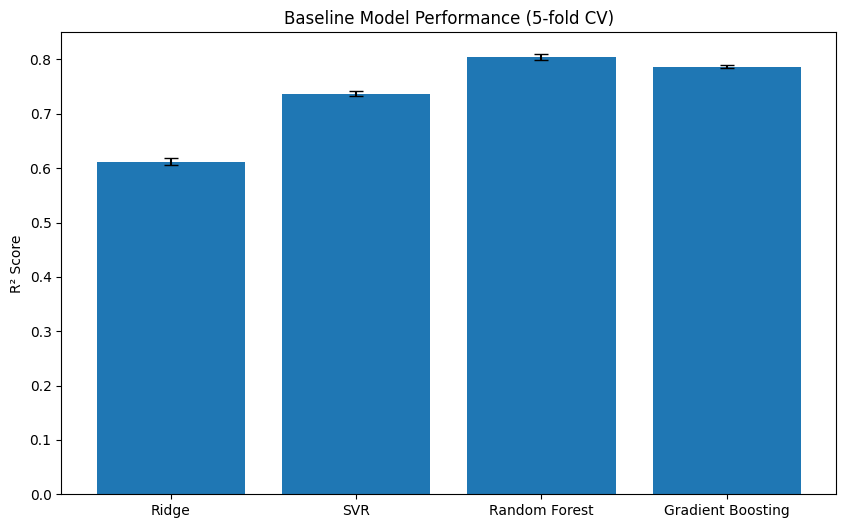

In [84]:
# TODO: Visualize baseline model performance with a bar plot
plt.figure(figsize=(10, 6))
plt.bar(baseline_df.index, baseline_df['R2_mean'], yerr=baseline_df['R2_std'], capsize=5)
plt.ylabel('R² Score')
plt.title('Baseline Model Performance (5-fold CV)')
plt.show()

## Part 3: Grid Search

In [85]:
# TODO: Define parameter grids for each model
param_grids = {
    'Ridge': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'SVR': {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1], 'kernel': ['rbf', 'linear']},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 20, None], 'min_samples_split': [2, 5, 10]},
    'Gradient Boosting': {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]}
}

In [86]:
# TODO: Function that performs grid search
def run_grid_search(model, param_grid, X_train, y_train):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
    start = time.time()
    grid.fit(X_train, y_train)
    elapsed = time.time() - start
    return grid.best_estimator_, grid.best_params_, grid.best_score_, elapsed

In [ ]:
# TODO: Apply grid search to all models
grid_results = {}
for name, model in models.items():
    best_model, best_params, best_score, elapsed = run_grid_search(model, param_grids[name], X_train_scaled, y_train)
    grid_results[name] = {'best_model': best_model, 'best_params': best_params, 'best_score': best_score, 'time': elapsed}
    print(f"{name}: Best R² = {best_score:.4f}, Time = {elapsed:.2f}s, Params = {best_params}")

Ridge: Best R² = 0.6115, Time = 2.83s, Params = {'alpha': 0.01}
